In [71]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score

In [72]:
df = pd.read_excel(r"C:\Users\kiran\Downloads\customer_segmentation_kmeans_12k.xlsx")
df.head()

,Name,Age,Income,Spending Score
0,Customer_1,30,36839,16
1,Customer_2,29,56080,61
2,Customer_3,66,15644,47
3,Customer_4,56,72358,31
4,Customer_5,37,36871,25


In [73]:
df = df.drop("Name", axis=1)

In [74]:
X = df[['Income', 'Spending Score']]

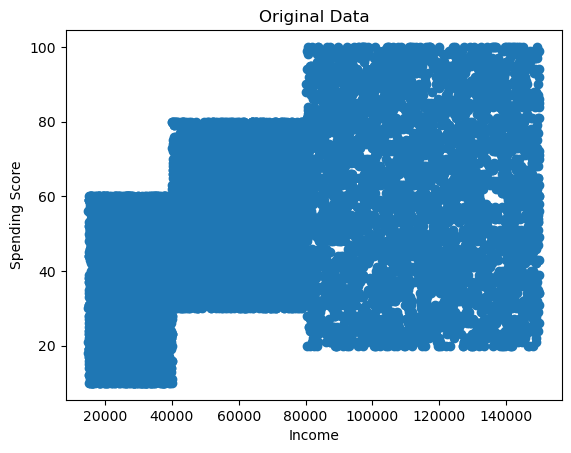

In [75]:
plt.scatter(X['Income'], X['Spending Score'])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Original Data")
plt.show()

In [76]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

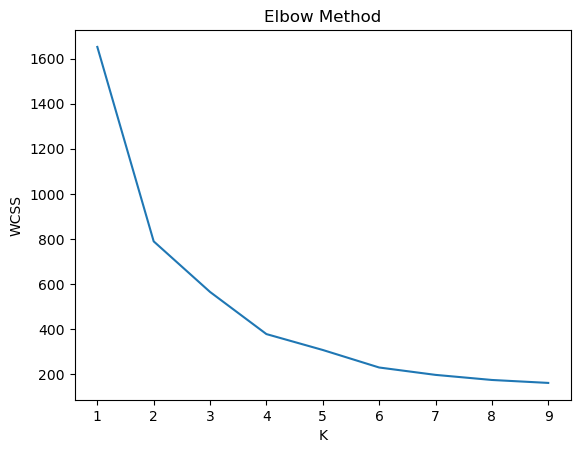

In [77]:
wcss = []
for k in range(1, 10):
    model = KMeans(n_clusters=k)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.plot(range(1, 10), wcss)
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [78]:
model = KMeans(n_clusters=4)
labels= model.fit_predict(X_scaled)

In [81]:
labels

array([1, 0, 1, ..., 3, 1, 0])

In [83]:
df['Cluster'] = labels

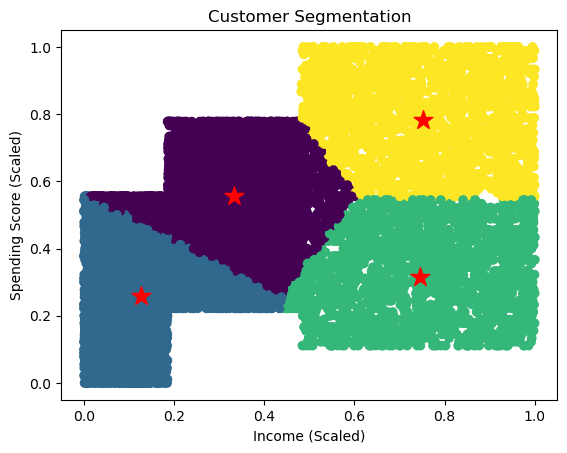

In [84]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels)


plt.scatter(model.cluster_centers_[:,0],
            model.cluster_centers_[:,1],
            color='red', marker='*', s=200)

plt.xlabel("Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.title("Customer Segmentation")
plt.show()